In [24]:
import geodatasets
import geopandas
import geopandas.datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn
import urllib.request

# 1. Exploración y comprensión de los datos

## 1.1. Descargar

In [25]:
filename = "df.csv"
if not os.path.exists(filename):
  urllib.request.urlretrieve("https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv", filename)
df = pd.read_csv(filename)

## 1.2. Verificar

In [26]:
df.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [27]:
df.tail()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.25, 17.66667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"
45715,Zulu Queen,30414,Valid,L3.7,200.0,Found,1976.0,33.98333,-115.68333,"(33.98333, -115.68333)"


## 1.3. Optimizar

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  str    
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  str    
 3   recclass     45716 non-null  str    
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  str    
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 3.5 MB


In [29]:
df.drop(columns=['GeoLocation'], inplace=True)
df.dropna(inplace=True)
df = df[sorted(df.columns)]
df = df.astype({
    'fall': 'category',
    'id': 'int32',
    'mass (g)': 'float32',
    'nametype': 'category',
    'recclass': 'category',
    'reclat': 'float32',
    'reclong': 'float32',
    'year': 'int32',
})
df.info()

<class 'pandas.DataFrame'>
Index: 38115 entries, 0 to 45715
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   fall      38115 non-null  category
 1   id        38115 non-null  int32   
 2   mass (g)  38115 non-null  float32 
 3   name      38115 non-null  str     
 4   nametype  38115 non-null  category
 5   recclass  38115 non-null  category
 6   reclat    38115 non-null  float32 
 7   reclong   38115 non-null  float32 
 8   year      38115 non-null  int32   
dtypes: category(3), float32(3), int32(2), str(1)
memory usage: 1.5 MB


# 2. Estadística descriptiva

In [30]:
df.describe()

,id,mass (g),reclat,reclong,year
count,38115.000000,3.811500e+04,38115.000000,38115.000000,38115.000000
mean,25343.139000,1.560071e+04,-39.596531,61.309361,1989.993913
std,17395.360205,6.286818e+05,46.175831,80.777580,25.469892
min,1.000000,0.000000e+00,-87.366669,-165.433334,860.000000
25%,10831.500000,6.630000e+00,-76.716667,0.000000,1986.000000
50%,21732.000000,2.909000e+01,-71.500000,35.666672,1996.000000
75%,39887.500000,1.872900e+02,0.000000,157.166672,2002.000000
max,57458.000000,6.000000e+07,81.166672,178.199997,2101.000000


## 2.1. Variables numéricas

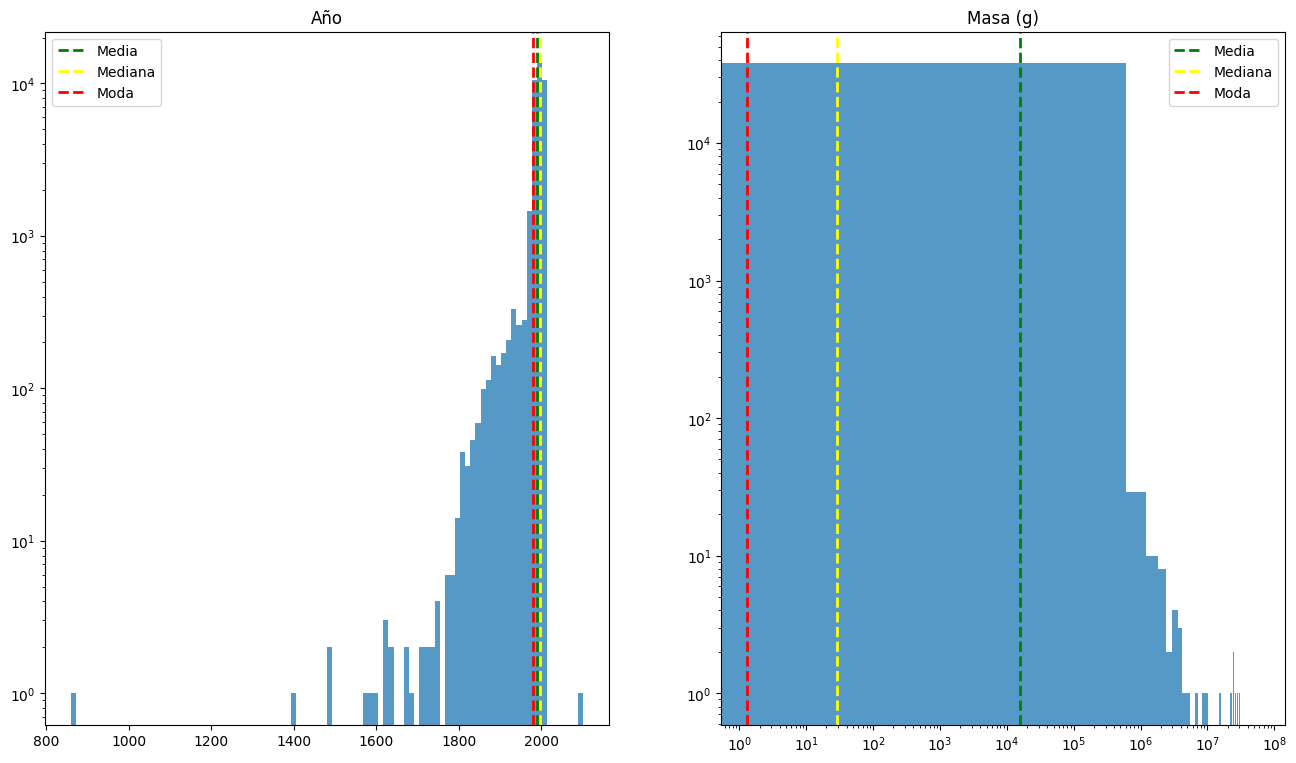

In [31]:
_, ax = plt.subplots(1, 2, figsize=(16, 9))

ax[0].axvline(df['year'].mean(), color='green', ls='--', lw=2, label='Media')
ax[0].axvline(df['year'].median(), color='yellow', ls='--', lw=2, label='Mediana')
ax[0].axvline(df['year'].mode()[0], color='red', ls='--', lw=2, label='Moda')
ax[0].hist(df['year'], alpha=0.75, bins=100)
ax[0].legend()
ax[0].set_title('Año')
ax[0].set_yscale('log')

ax[1].axvline(df['mass (g)'].mean(), color='green', ls='--', lw=2, label='Media')
ax[1].axvline(df['mass (g)'].median(), color='yellow', ls='--', lw=2, label='Mediana')
ax[1].axvline(df['mass (g)'].mode()[0], color='red', ls='--', lw=2, label='Moda')
ax[1].hist(df['mass (g)'], alpha=0.75, bins=100)
ax[1].legend()
ax[1].set_title('Masa (g)')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

plt.show()

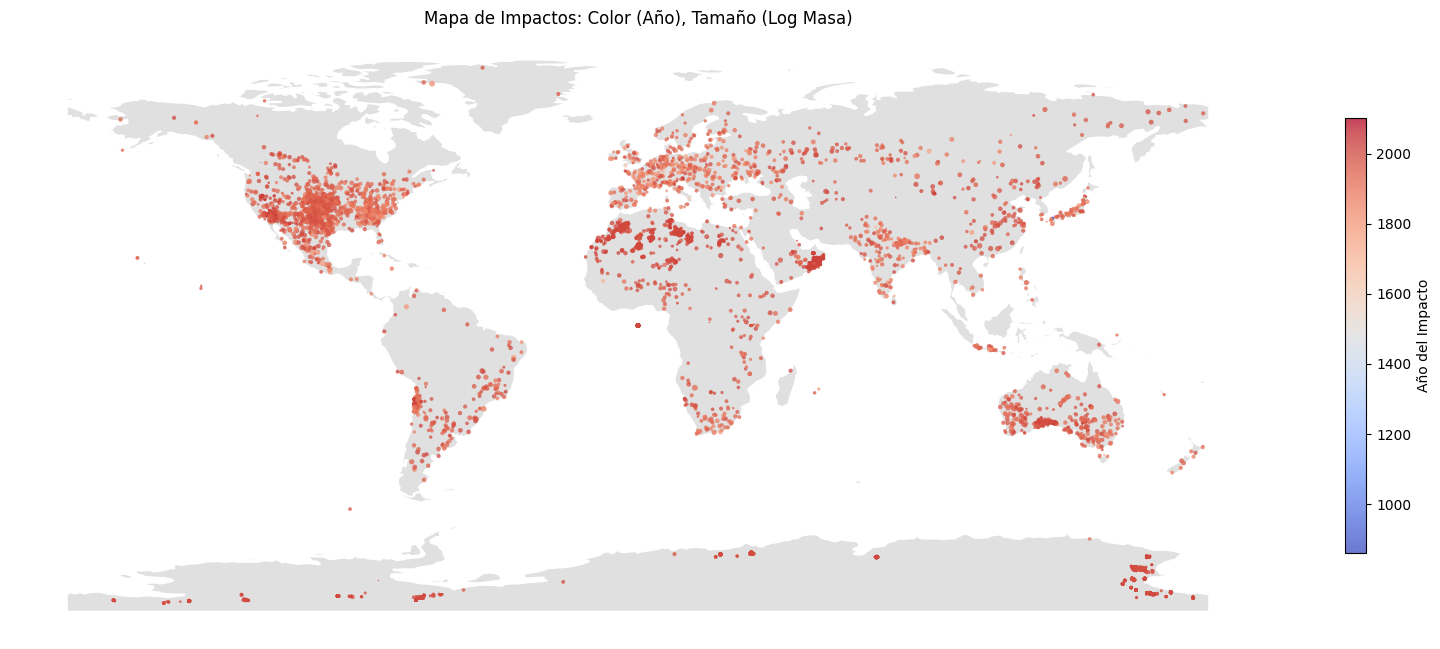

In [32]:
_, ax = plt.subplots(figsize=(16, 9))

ax.set_axis_off()
ax.set_title('Mapa de Impactos: Color (Año), Tamaño (Log Masa)')

geoDataFrame: geopandas.GeoDataFrame = geopandas.read_file(geodatasets.get_path('naturalearth.land'))
geoDataFrame.plot(ax=ax, color='#e0e0e0', edgecolor='#ffffff')

pathCollection = ax.scatter(df['reclong'], df['reclat'], alpha=0.75, c=df['year'], cmap='coolwarm', edgecolors='none', s=np.log(1 + df['mass (g)']))

plt.colorbar(pathCollection, label='Año del Impacto', shrink=0.5)
plt.tight_layout()
plt.show()

## 2.2. Variables categóricas

In [33]:
df.describe(include='category')

,fall,nametype,recclass
count,38115,38115,38115
unique,2,2,422
top,Found,Valid,L6
freq,37050,38094,7519


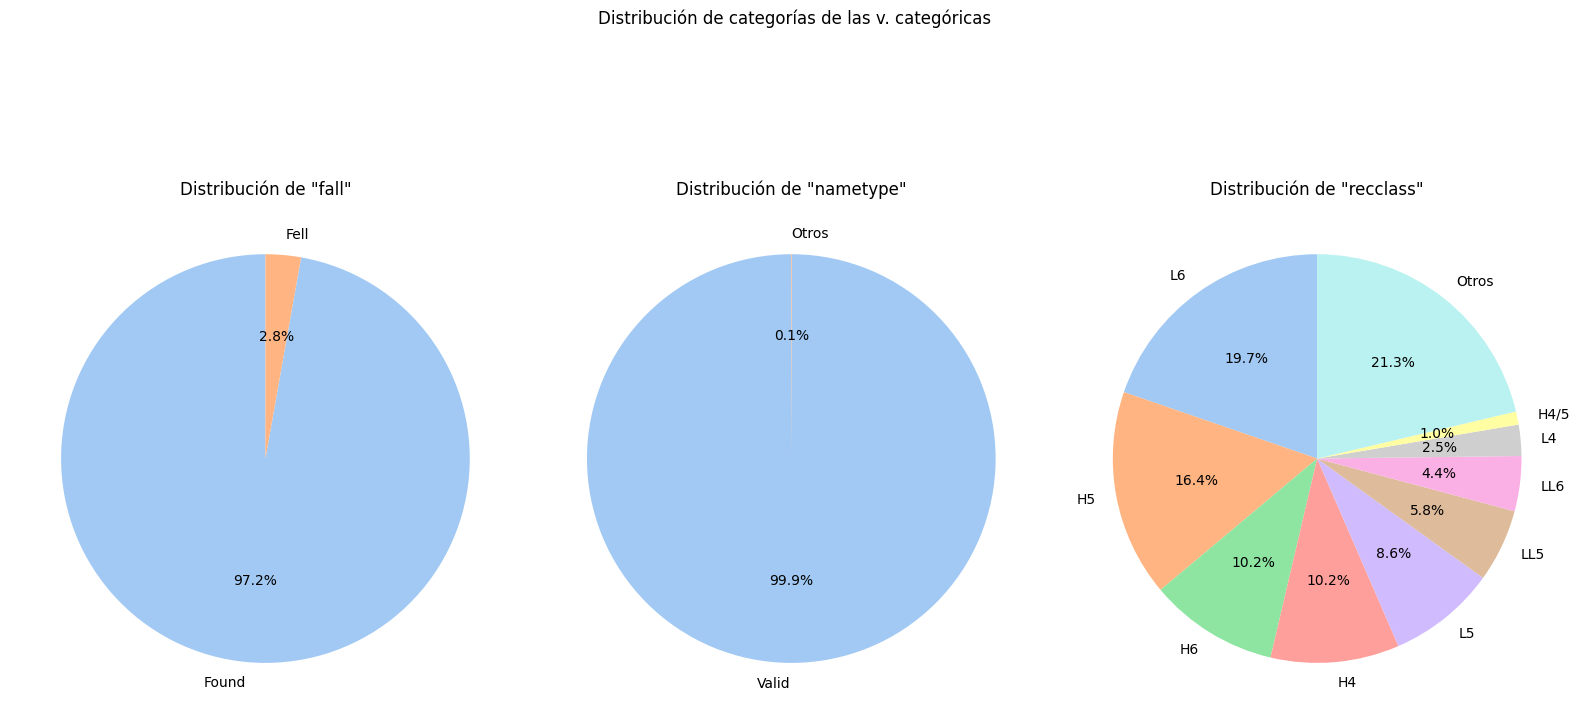

In [34]:
_, ax = plt.subplots(1, 3, figsize=(16, 9))

for i, column in enumerate(["fall", "nametype", "recclass"]):
    counts = df[column].value_counts(normalize=True)

    mask = counts < 0.01
    if mask.any():
        counts_filtered = counts[~mask].copy()
        counts_filtered["Otros"] = counts[mask].sum()
    else:
        counts_filtered = counts

    ax[i].pie(counts_filtered, autopct="%1.1f%%", colors=seaborn.color_palette("pastel"), labels=counts_filtered.index, startangle=90)
    ax[i].set_title(f'Distribución de "{column}"')

plt.suptitle('Distribución de categorías de las v. categóricas')
plt.tight_layout()
plt.show()

## 2.3. Relaciones entre variables